In [2]:
# ============================================
# EDA ANALYSIS
# Mutual Fund Analytics Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# --------------------------------------------
# PROJECT PATH
# --------------------------------------------

PROJECT_ROOT = Path.cwd().parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
REPORTS = PROJECT_ROOT / "reports"
DASHBOARD = PROJECT_ROOT / "dashboard"

print("Libraries imported successfully")
print("Project root:", PROJECT_ROOT)

Libraries imported successfully
Project root: c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone


In [4]:
# ============================================
# 2. LOAD PROCESSED DATASETS
# ============================================

# NAV history
nav = pd.read_csv(
    DATA_PROCESSED / "02_nav_history_clean.csv"
)

# Scheme performance
performance = pd.read_csv(
    DATA_PROCESSED / "07_scheme_performance_clean.csv"
)

# Investor transactions
transactions = pd.read_csv(
    DATA_PROCESSED / "08_investor_transactions_clean.csv"
)

# --------------------------------------------
# Display shapes
# --------------------------------------------

print("NAV History:", nav.shape)
print("Scheme Performance:", performance.shape)
print("Investor Transactions:", transactions.shape)

print("\nAll three datasets loaded successfully.")

NAV History: (46000, 3)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)

All three datasets loaded successfully.


In [6]:
# ============================================
# 3. DATASET OVERVIEW
# ============================================

print("========== NAV HISTORY ==========")
print(nav.head())

print("\nNAV columns:")
print(nav.columns.tolist())


print("\n========== SCHEME PERFORMANCE ==========")
print(performance.head())

print("\nPerformance columns:")
print(performance.columns.tolist())


print("\n========== INVESTOR TRANSACTIONS ==========")
print(transactions.head())

print("\nTransaction columns:")
print(transactions.columns.tolist())

========== NAV HISTORY ==========
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

NAV columns:
['amfi_code', 'date', 'nav']

========== SCHEME PERFORMANCE ==========
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11

In [8]:
# ============================================
# 4. BASIC DATA QUALITY CHECK
# ============================================

print("NAV missing values:")
print(nav.isnull().sum())

print("\nPerformance missing values:")
print(performance.isnull().sum())

print("\nTransaction missing values:")
print(transactions.isnull().sum())

NAV missing values:
amfi_code    0
date         0
nav          0
dtype: int64

Performance missing values:
amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

Transaction missing values:
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64


In [10]:
# ============================================
# 5. NAV TREND ANALYSIS
# ============================================

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(
    ["amfi_code", "date"]
)

print("NAV date range:")
print(nav["date"].min(), "to", nav["date"].max())

print("Number of schemes:", nav["amfi_code"].nunique())

NAV date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00
Number of schemes: 40


In [12]:
# ============================================
# 6. DAILY NAV TREND - ALL SCHEMES
# ============================================

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend - All Mutual Fund Schemes",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

fig.update_layout(
    template="plotly_white",
    height=700
)

fig.show()

# Save interactive chart
fig.write_html(
    DASHBOARD / "nav_trend.html"
)

print("NAV trend chart created successfully")

NAV trend chart created successfully


In [14]:
# ============================================
# 7. DAILY NAV RETURNS
# ============================================

nav["daily_return"] = (
    nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily returns calculated successfully")

print(
    nav[
        [
            "amfi_code",
            "date",
            "nav",
            "daily_return"
        ]
    ].head(10)
)

Daily returns calculated successfully
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [20]:
# ============================================
# 8. CHECK AUM DATA
# ============================================

print("Performance columns:")
print(performance.columns.tolist())

print("\nFirst 5 rows:")
display(performance.head())

Performance columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

First 5 rows:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


AUM rows available: 40

AUM statistics:
count       40.00000
mean     26091.60000
std      13809.11134
min        979.00000
25%      17400.50000
50%      26713.00000
75%      38125.00000
max      49046.00000
Name: aum_crore, dtype: float64

Top 15 Funds by AUM:
                                          scheme_name  aum_crore
Mirae Asset Emerging Bluechip Fund - Regular - Growth      49046
        Kotak Emerging Equity Fund - Regular - Growth      47469
       Nippon India Small Cap Fund - Regular - Growth      43630
           DSP Top 100 Equity Fund - Regular - Growth      41828
                  UTI Mid Cap Fund - Regular - Growth      41728
               ABSL Small Cap Fund - Regular - Growth      41613
            ICICI Pru Bluechip Fund - Direct - Growth      41553
        Nippon India Large Cap Fund - Direct - Growth      39475
             ICICI Pru Liquid Fund - Regular - Growth      39116
                  ABSL Liquid Fund - Regular - Growth      38995
                   DSP 

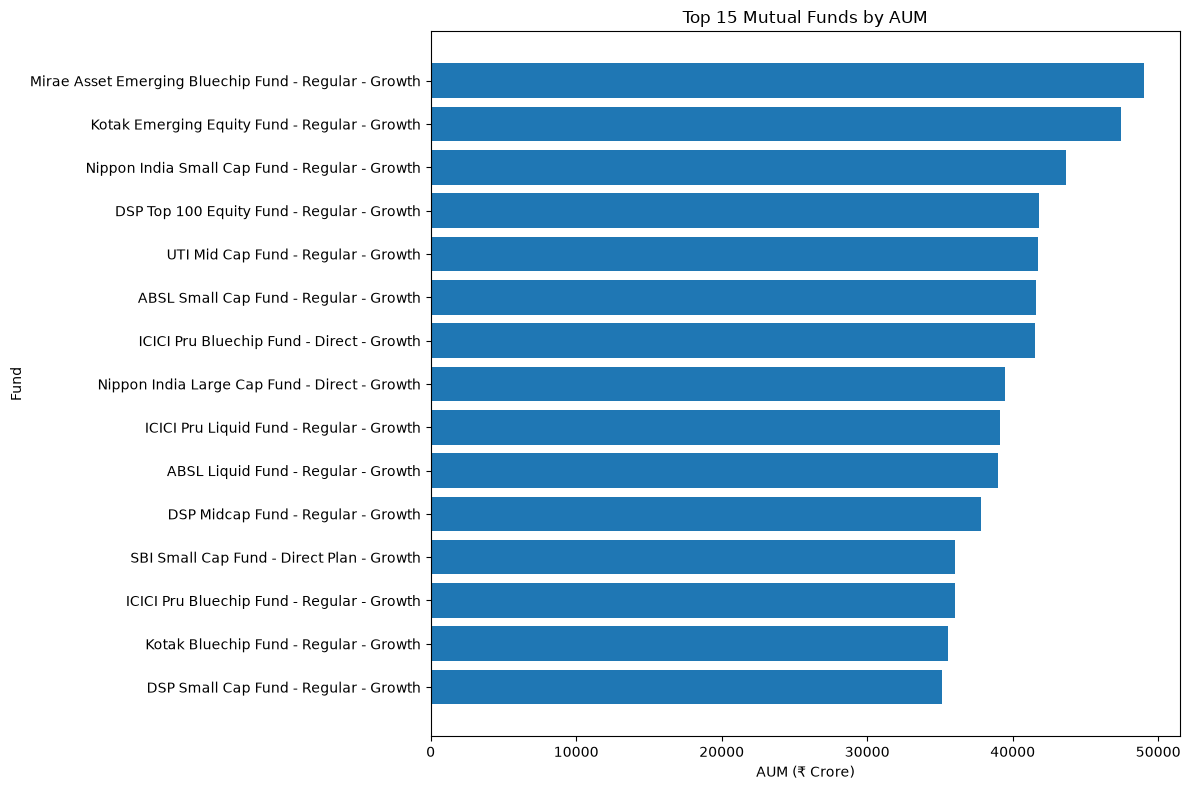


AUM chart created successfully


In [22]:
# ============================================
# 9. AUM ANALYSIS
# ============================================

# Convert AUM to numeric
performance["aum_crore"] = pd.to_numeric(
    performance["aum_crore"],
    errors="coerce"
)

# Remove missing AUM
aum_data = performance.dropna(
    subset=["aum_crore"]
).copy()

print("AUM rows available:", len(aum_data))

print("\nAUM statistics:")
print(aum_data["aum_crore"].describe())


# --------------------------------------------
# TOP 15 FUNDS BY AUM
# --------------------------------------------

top_aum = (
    aum_data[
        ["scheme_name", "aum_crore"]
    ]
    .sort_values(
        "aum_crore",
        ascending=False
    )
    .head(15)
)

print("\nTop 15 Funds by AUM:")
print(top_aum.to_string(index=False))


# --------------------------------------------
# BAR CHART
# --------------------------------------------

plt.figure(figsize=(12, 8))

plt.barh(
    top_aum["scheme_name"],
    top_aum["aum_crore"]
)

plt.xlabel("AUM (₹ Crore)")
plt.ylabel("Fund")
plt.title("Top 15 Mutual Funds by AUM")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    DASHBOARD / "aum_top_15.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nAUM chart created successfully")

In [24]:
print("\nSample data:")
display(performance.head())


Sample data:


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [26]:
# ============================================
# 10. CHECK COLUMNS FOR AUM GROWTH ANALYSIS
# ============================================

print("All Performance Dataset Columns:\n")

for i, col in enumerate(performance.columns):
    print(i, ":", col)

All Performance Dataset Columns:

0 : amfi_code
1 : scheme_name
2 : fund_house
3 : category
4 : plan
5 : return_1yr_pct
6 : return_3yr_pct
7 : return_5yr_pct
8 : benchmark_3yr_pct
9 : alpha
10 : beta
11 : sharpe_ratio
12 : sortino_ratio
13 : std_dev_ann_pct
14 : max_drawdown_pct
15 : aum_crore
16 : expense_ratio_pct
17 : morningstar_rating
18 : risk_grade


In [28]:
# ============================================
# 10. FIND AUM DATASET
# ============================================

import glob

csv_files = glob.glob(
    str(DATA_PROCESSED / "*.csv")
) + glob.glob(
    str(DATA_RAW / "*.csv")
)

print("CSV files found:\n")

for file in csv_files:
    print(Path(file).name)

CSV files found:

02_nav_history_clean.csv
07_scheme_performance_clean.csv
08_investor_transactions_clean.csv
Axis_Bluechip.csv
ICICI_Bluechip.csv
Kotak_Bluechip.csv
live_nav_history.csv
nav_with_daily_returns.csv
Nippon_Large_Cap.csv
SBI_Bluechip.csv
01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv


In [30]:
# ============================================
# 11. FIND AUM COLUMNS
# ============================================

for file in csv_files:

    try:
        temp = pd.read_csv(file, nrows=5)

        columns = temp.columns.tolist()

        if (
            "fund_house" in columns
            and "aum_crore" in columns
        ):

            print("\nAUM DATASET FOUND:")
            print(Path(file).name)

            print("\nColumns:")
            print(columns)

    except Exception as e:
        print(
            "Could not read:",
            Path(file).name
        )


AUM DATASET FOUND:
07_scheme_performance_clean.csv

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

AUM DATASET FOUND:
03_aum_by_fund_house.csv

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

AUM DATASET FOUND:
07_scheme_performance.csv

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [33]:
# ============================================
# 12. FIND AND LOAD AUM DATASET
# ============================================

from pathlib import Path

aum_file = None

# Search both processed and raw folders
for folder in [DATA_PROCESSED, DATA_RAW]:

    candidate = folder / "03_aum_by_fund_house.csv"

    if candidate.exists():
        aum_file = candidate
        break

if aum_file is None:
    raise FileNotFoundError(
        "03_aum_by_fund_house.csv was not found "
        "in data/raw or data/processed."
    )

print("AUM file found at:")
print(aum_file)

# Load file
aum = pd.read_csv(aum_file)

print("\nAUM dataset loaded successfully")
print("Shape:", aum.shape)

print("\nColumns:")
print(aum.columns.tolist())

display(aum.head())

AUM file found at:
c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone\data\raw\03_aum_by_fund_house.csv

AUM dataset loaded successfully
Shape: (90, 5)

Columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [35]:
# ============================================
# 13. PREPARE AUM DATA
# ============================================

aum["date"] = pd.to_datetime(
    aum["date"],
    errors="coerce"
)

aum["aum_lakh_crore"] = pd.to_numeric(
    aum["aum_lakh_crore"],
    errors="coerce"
)

aum = aum.dropna(
    subset=[
        "date",
        "fund_house",
        "aum_lakh_crore"
    ]
).copy()

aum["year"] = aum["date"].dt.year

aum = aum[
    aum["year"].between(2022, 2025)
].copy()

print("Years available:")
print(sorted(aum["year"].unique()))

print("\nFund houses:")
print(aum["fund_house"].unique())

Years available:
[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]

Fund houses:
<StringArray>
[         'SBI Mutual Fund',      'ICICI Prudential MF',
         'HDFC Mutual Fund',          'Nippon India MF',
        'Kotak Mahindra MF', 'Aditya Birla Sun Life MF',
         'Axis Mutual Fund',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str


In [37]:
# ============================================
# 14. YEAR-END AUM BY FUND HOUSE
# ============================================

# Sort by fund house, year and date
aum = aum.sort_values(
    ["fund_house", "year", "date"]
)

# Take the latest available AUM observation
# for each fund house in each year
aum_yearly = (
    aum
    .groupby(
        ["fund_house", "year"],
        as_index=False
    )
    .last()
)

print("Year-end AUM data:")
display(
    aum_yearly[
        [
            "fund_house",
            "year",
            "aum_lakh_crore"
        ]
    ].sort_values(
        ["year", "aum_lakh_crore"],
        ascending=[True, False]
    )
)

Year-end AUM data:


,fund_house,year,aum_lakh_crore
32,SBI Mutual Fund,2022,6.30
16,ICICI Prudential MF,2022,4.88
12,HDFC Mutual Fund,2022,4.45
0,Aditya Birla Sun Life MF,2022,2.85
28,Nippon India MF,2022,2.78
20,Kotak Mahindra MF,2022,2.72
4,Axis Mutual Fund,2022,2.40
36,UTI Mutual Fund,2022,2.32
8,DSP Mutual Fund,2022,1.12
24,Mirae Asset MF,2022,1.08


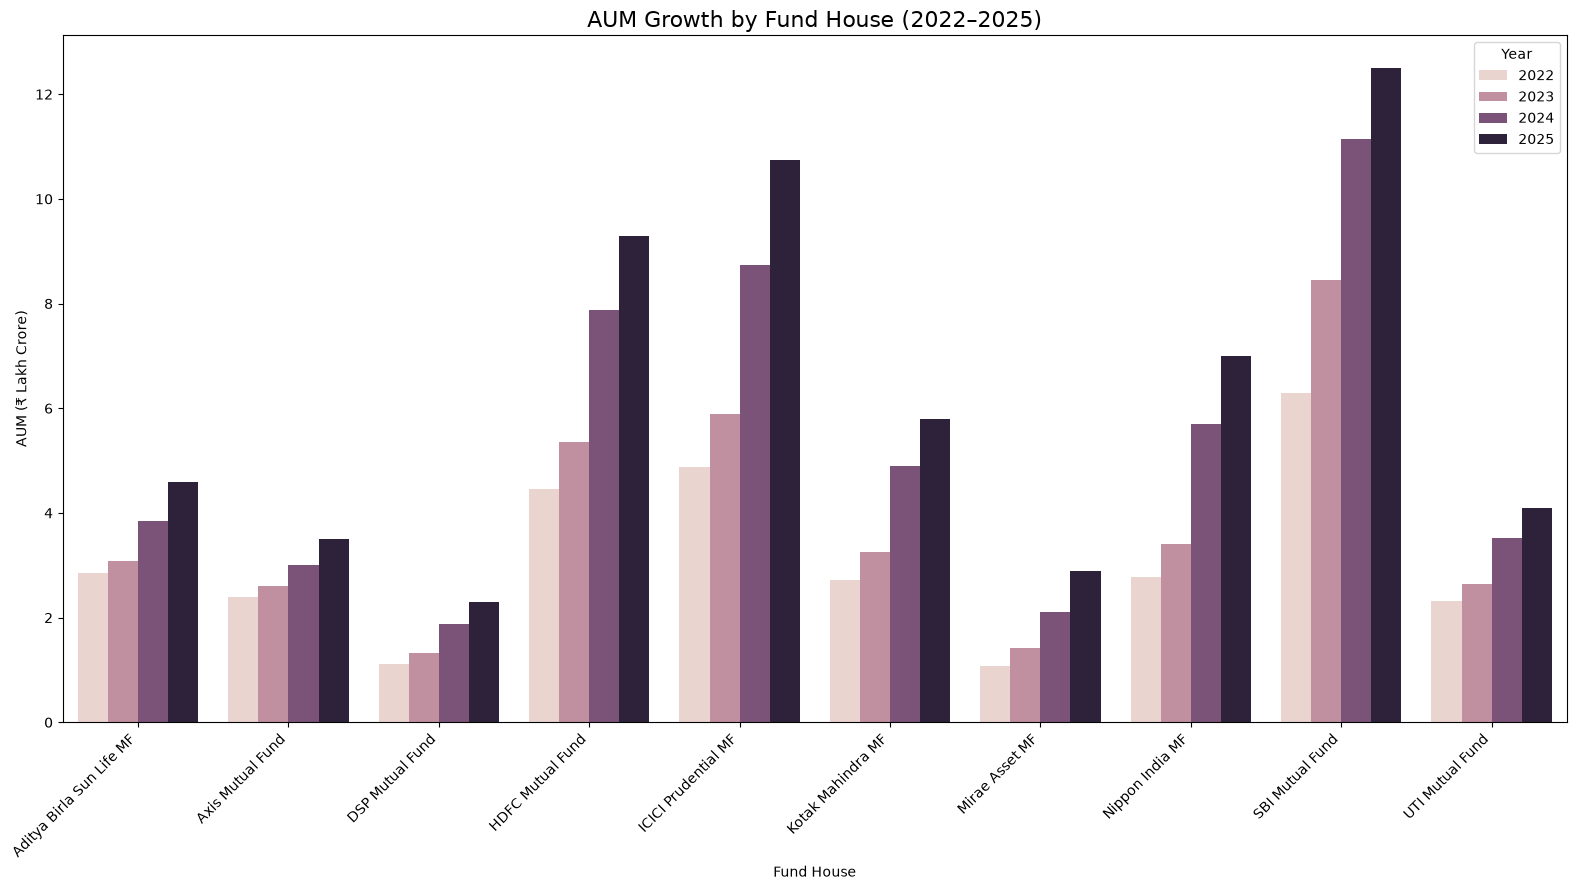

AUM growth chart created successfully.


In [39]:
# ============================================
# 15. AUM GROWTH CHART 2022-2025
# ============================================

plt.figure(figsize=(16, 9))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022–2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Year"
)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "aum_growth_by_fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("AUM growth chart created successfully.")

In [41]:
# ============================================
# 16. SBI MUTUAL FUND AUM
# ============================================

sbi = aum_yearly[
    aum_yearly["fund_house"]
    .astype(str)
    .str.contains(
        "SBI",
        case=False,
        na=False
    )
].copy()

print("SBI Mutual Fund AUM:")
display(
    sbi[
        [
            "fund_house",
            "year",
            "aum_lakh_crore"
        ]
    ].sort_values("year")
)

SBI Mutual Fund AUM:


,fund_house,year,aum_lakh_crore
32,SBI Mutual Fund,2022,6.30
33,SBI Mutual Fund,2023,8.45
34,SBI Mutual Fund,2024,11.14
35,SBI Mutual Fund,2025,12.50


In [43]:
# ============================================
# 17. FIND SIP DATASET
# ============================================

sip_file = None

for folder in [DATA_PROCESSED, DATA_RAW]:

    for file in folder.glob("*.csv"):

        try:
            temp = pd.read_csv(file, nrows=5)

            columns = temp.columns.tolist()

            if (
                "month" in columns
                and "sip_inflow_crore" in columns
            ):
                sip_file = file
                break

        except Exception:
            pass

    if sip_file is not None:
        break


if sip_file is None:

    raise FileNotFoundError(
        "SIP dataset not found."
    )


print("SIP dataset found:")
print(sip_file)

sip = pd.read_csv(sip_file)

print("\nShape:", sip.shape)

print("\nColumns:")
print(sip.columns.tolist())

display(sip.head())

SIP dataset found:
c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone\data\raw\04_monthly_sip_inflows.csv

Shape: (48, 6)

Columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [45]:
# ============================================
# 18. PREPARE SIP DATA
# ============================================

sip["month"] = pd.to_datetime(
    sip["month"],
    errors="coerce"
)

sip["sip_inflow_crore"] = pd.to_numeric(
    sip["sip_inflow_crore"],
    errors="coerce"
)

sip = sip.dropna(
    subset=[
        "month",
        "sip_inflow_crore"
    ]
).copy()

# Keep January 2022 to December 2025
sip = sip[
    (
        sip["month"] >= "2022-01-01"
    )
    &
    (
        sip["month"] <= "2025-12-31"
    )
].copy()

sip = sip.sort_values("month")

print(
    "SIP period:",
    sip["month"].min(),
    "to",
    sip["month"].max()
)

print(
    "Number of months:",
    len(sip)
)

SIP period: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 48


In [47]:
# ============================================
# 18. PREPARE SIP DATA
# ============================================

sip["month"] = pd.to_datetime(
    sip["month"],
    errors="coerce"
)

sip["sip_inflow_crore"] = pd.to_numeric(
    sip["sip_inflow_crore"],
    errors="coerce"
)

sip = sip.dropna(
    subset=[
        "month",
        "sip_inflow_crore"
    ]
).copy()

# Keep January 2022 to December 2025
sip = sip[
    (
        sip["month"] >= "2022-01-01"
    )
    &
    (
        sip["month"] <= "2025-12-31"
    )
].copy()

sip = sip.sort_values("month")

print(
    "SIP period:",
    sip["month"].min(),
    "to",
    sip["month"].max()
)

print(
    "Number of months:",
    len(sip)
)

SIP period: 2022-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 48


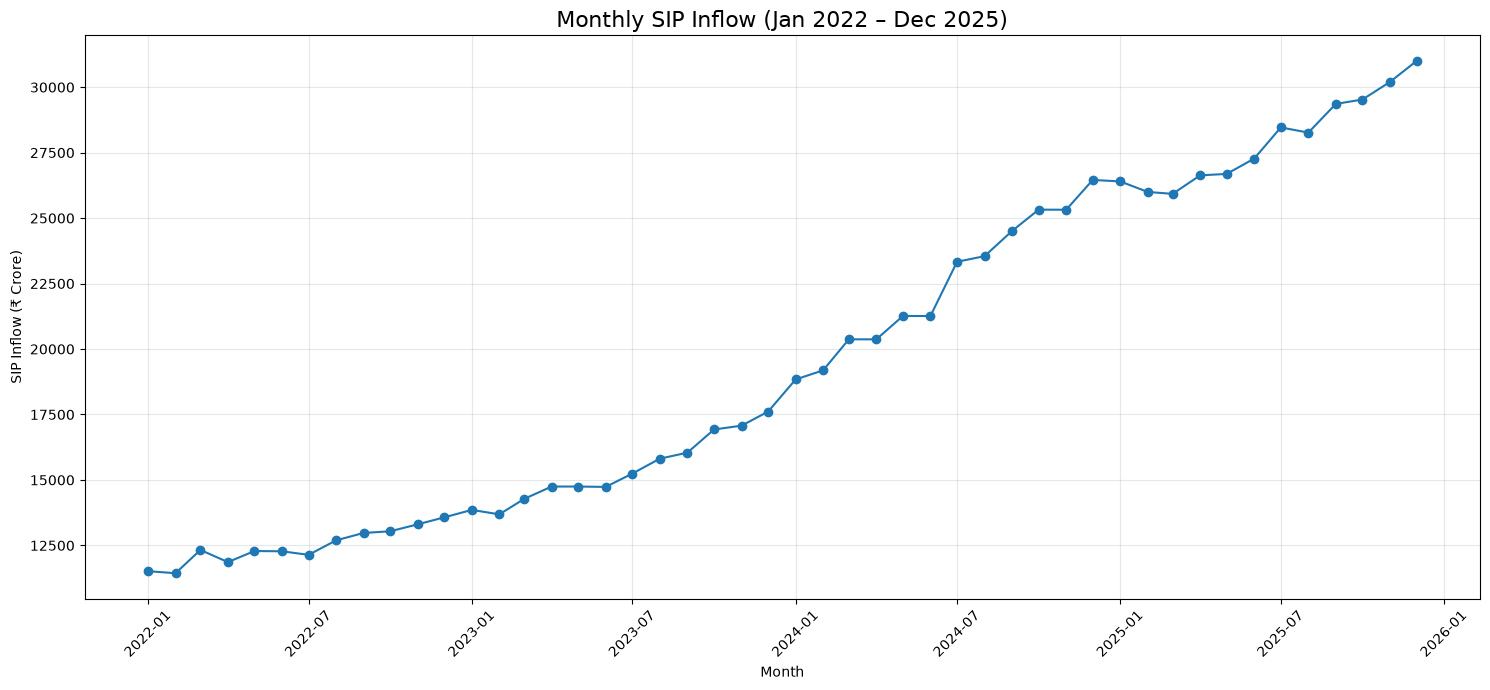

In [49]:
# ============================================
# 19. SIP INFLOW TIME SERIES
# ============================================

plt.figure(figsize=(15, 7))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title(
    "Monthly SIP Inflow (Jan 2022 – Dec 2025)",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.xticks(rotation=45)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
# ============================================
# 20. DECEMBER 2025 SIP INFLOW
# ============================================

dec_2025 = sip[
    (
        sip["month"].dt.year == 2025
    )
    &
    (
        sip["month"].dt.month == 12
    )
]

if not dec_2025.empty:

    dec_value = (
        dec_2025["sip_inflow_crore"]
        .iloc[0]
    )

    print(
        f"December 2025 SIP inflow: "
        f"₹{dec_value:,.2f} Crore"
    )

else:

    print(
        "December 2025 data not found."
    )

December 2025 SIP inflow: ₹31,002.00 Crore


In [53]:
# ============================================
# 21. FIND CATEGORY INFLOW DATASET
# ============================================

category_file = None

for folder in [DATA_PROCESSED, DATA_RAW]:

    for file in folder.glob("*.csv"):

        try:
            temp = pd.read_csv(file, nrows=5)

            columns = temp.columns.tolist()

            # Look for category + month + inflow
            has_category = "category" in columns
            has_month = "month" in columns

            inflow_column = None

            for col in columns:
                if "inflow" in col.lower():
                    inflow_column = col
                    break

            if (
                has_category
                and has_month
                and inflow_column is not None
            ):
                category_file = file
                break

        except Exception:
            pass

    if category_file is not None:
        break


if category_file is None:
    raise FileNotFoundError(
        "Category inflow dataset not found."
    )


print("Category inflow dataset found:")
print(category_file)

category_inflow = pd.read_csv(
    category_file
)

print("\nShape:")
print(category_inflow.shape)

print("\nColumns:")
print(category_inflow.columns.tolist())

display(
    category_inflow.head()
)

Category inflow dataset found:
c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone\data\raw\05_category_inflows.csv

Shape:
(144, 3)

Columns:
['month', 'category', 'net_inflow_crore']


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [55]:
# ============================================
# 22. CHECK INFLOW COLUMN
# ============================================

print("Possible inflow columns:")

for col in category_inflow.columns:

    if "inflow" in col.lower():

        print(col)

Possible inflow columns:
net_inflow_crore


In [57]:
# ============================================
# 23. CHECK CATEGORY DATA
# ============================================

print("Categories:")

print(
    category_inflow["category"]
    .dropna()
    .unique()
)

print("\nSample months:")

print(
    category_inflow["month"]
    .head(10)
)

Categories:
<StringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str

Sample months:
0    2024-04
1    2024-04
2    2024-04
3    2024-04
4    2024-04
5    2024-04
6    2024-04
7    2024-04
8    2024-04
9    2024-04
Name: month, dtype: str


In [59]:
# ============================================
# 24. PREPARE CATEGORY INFLOW DATA
# ============================================

category_inflow["month"] = pd.to_datetime(
    category_inflow["month"],
    errors="coerce"
)

category_inflow["net_inflow_crore"] = pd.to_numeric(
    category_inflow["net_inflow_crore"],
    errors="coerce"
)

category_inflow = category_inflow.dropna(
    subset=[
        "month",
        "category",
        "net_inflow_crore"
    ]
).copy()

# Keep Jan 2022 - Dec 2025
category_inflow = category_inflow[
    (
        category_inflow["month"] >= "2022-01-01"
    )
    &
    (
        category_inflow["month"] <= "2025-12-31"
    )
].copy()

print("Category inflow data prepared")
print("Shape:", category_inflow.shape)

display(category_inflow.head())

Category inflow data prepared
Shape: (144, 3)


,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


Heatmap shape: (12, 12)


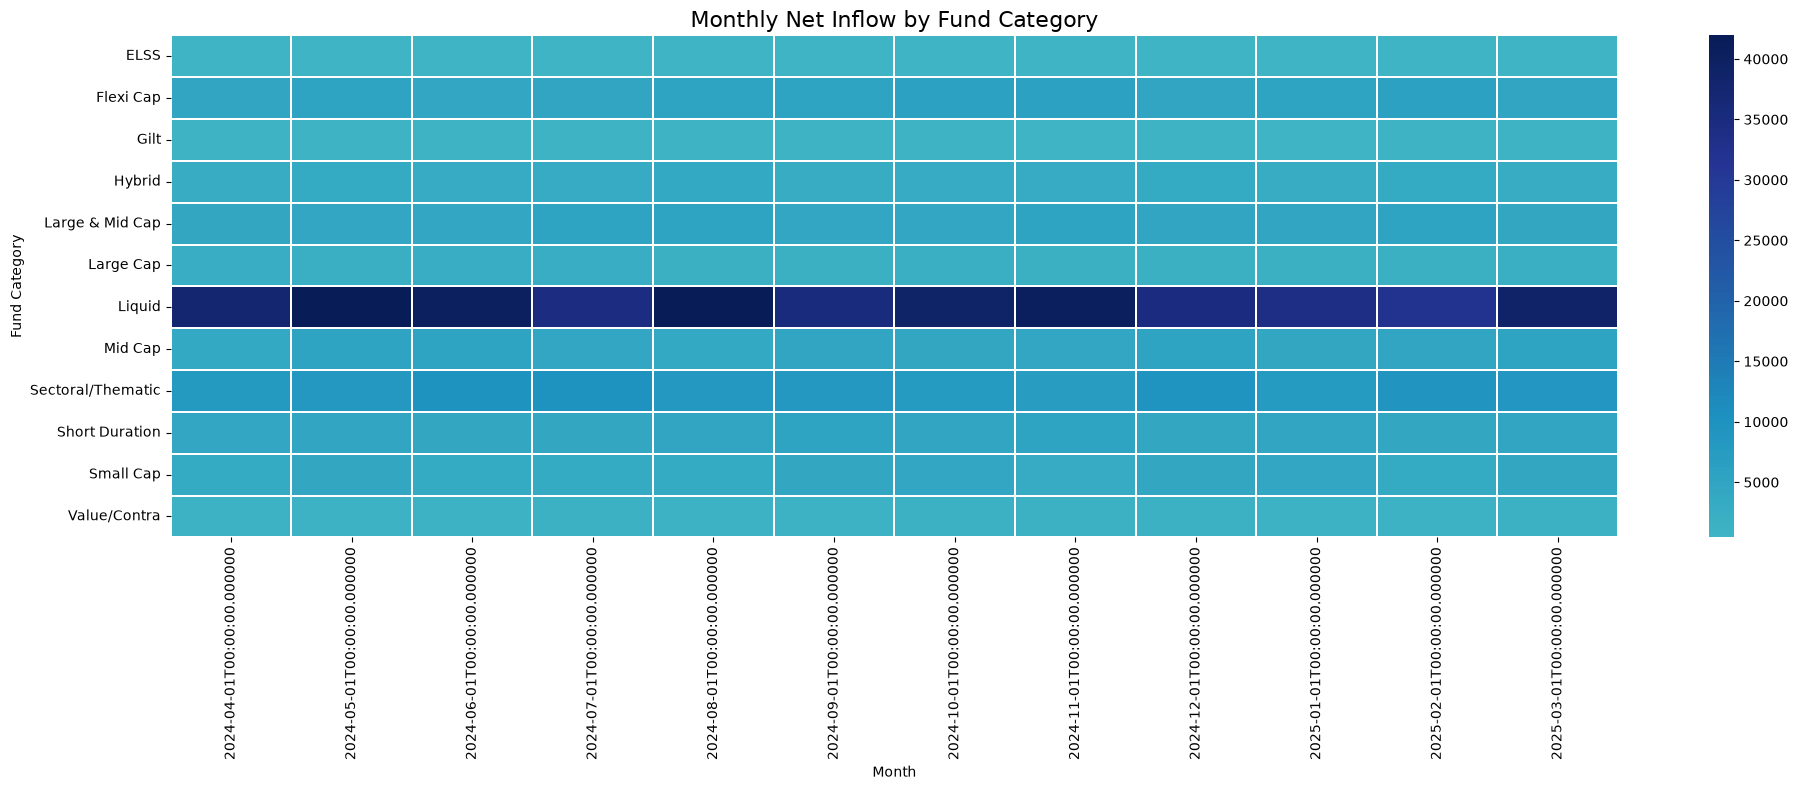

Category inflow heatmap created successfully.


In [61]:
# ============================================
# 25. CATEGORY INFLOW HEATMAP
# ============================================

heatmap_data = category_inflow.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

print("Heatmap shape:", heatmap_data.shape)

plt.figure(figsize=(20, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    center=0,
    linewidths=0.2
)

plt.title(
    "Monthly Net Inflow by Fund Category",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    DASHBOARD / "category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category inflow heatmap created successfully.")

In [63]:
# ============================================
# 26. INVESTOR DEMOGRAPHICS - CHECK COLUMNS
# ============================================

print("Transaction dataset columns:")

for i, col in enumerate(transactions.columns):
    print(i, ":", col)

Transaction dataset columns:
0 : investor_id
1 : transaction_date
2 : amfi_code
3 : transaction_type
4 : amount_inr
5 : state
6 : city
7 : city_tier
8 : age_group
9 : gender
10 : annual_income_lakh
11 : payment_mode
12 : kyc_status


In [66]:
# ============================================
# 27. DEMOGRAPHIC DATA PREVIEW
# ============================================

display(transactions.head())

print("\nUnique values for likely demographic columns:")

for col in [
    "age_group",
    "gender",
    "city_tier",
    "state",
    "city"
]:
    
    if col in transactions.columns:
        print(f"\n{col}:")
        print(
            transactions[col]
            .dropna()
            .unique()
        )

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending



Unique values for likely demographic columns:

age_group:
<StringArray>
['56+', '18-25', '36-45', '26-35', '46-55']
Length: 5, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

city_tier:
<StringArray>
['T30', 'B30']
Length: 2, dtype: str

state:
<StringArray>
[     'Telangana',         'Punjab',        'Haryana',    'Maharashtra',
          'Delhi', 'Madhya Pradesh',        'Gujarat',      'Rajasthan',
  'Uttar Pradesh',      'Karnataka',    'West Bengal',     'Tamil Nadu']
Length: 12, dtype: str

city:
<StringArray>
[ 'Hyderabad',   'Amritsar',  'Faridabad',     'Mumbai',      'Noida',
     'Bhopal',     'Nashik', 'Chandigarh',  'Ahmedabad',     'Jaipur',
       'Agra',     'Mysore',    'Kolkata', 'Coimbatore',   'Gurugram',
     'Indore',    'Chennai',    'Udaipur',      'Surat',  'Bangalore',
       'Pune',  'New Delhi',     'Kanpur',    'Lucknow']
Length: 24, dtype: str


In [68]:
# ============================================
# 28. PREPARE INVESTOR DEMOGRAPHICS
# ============================================

# Make amount numeric
transactions["amount_inr"] = pd.to_numeric(
    transactions["amount_inr"],
    errors="coerce"
)

# Remove rows missing demographic information
demo = transactions.dropna(
    subset=[
        "investor_id",
        "age_group",
        "gender"
    ]
).copy()

print("Demographic records:", len(demo))

print("\nAge groups:")
print(demo["age_group"].value_counts())

print("\nGender:")
print(demo["gender"].value_counts())

print("\nCity tiers:")
print(demo["city_tier"].value_counts())

Demographic records: 32778

Age groups:
age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

Gender:
gender
Male      21809
Female    10969
Name: count, dtype: int64

City tiers:
city_tier
T30    21719
B30    11059
Name: count, dtype: int64


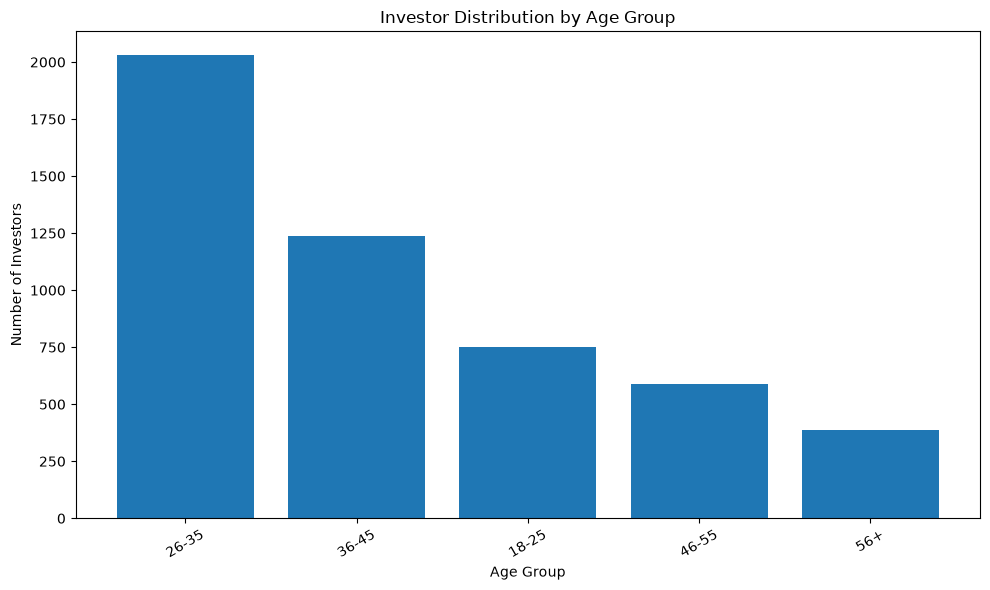

In [71]:
# ============================================
# 29. AGE GROUP DISTRIBUTION
# ============================================

age_counts = (
    demo.groupby("age_group")["investor_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    age_counts.index.astype(str),
    age_counts.values
)

plt.title(
    "Investor Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
# ============================================
# 30. SIP AMOUNT BY AGE GROUP
# ============================================

sip_demo = demo[
    demo["transaction_type"]
    .astype(str)
    .str.upper()
    .str.contains("SIP", na=False)
].copy()

sip_by_age = (
    sip_demo
    .groupby("age_group")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("SIP amount by age group:")
print(sip_by_age)

SIP amount by age group:
age_group
26-35    88587340
36-45    53623247
18-25    32300613
46-55    25614556
56+      17107735
Name: amount_inr, dtype: int64


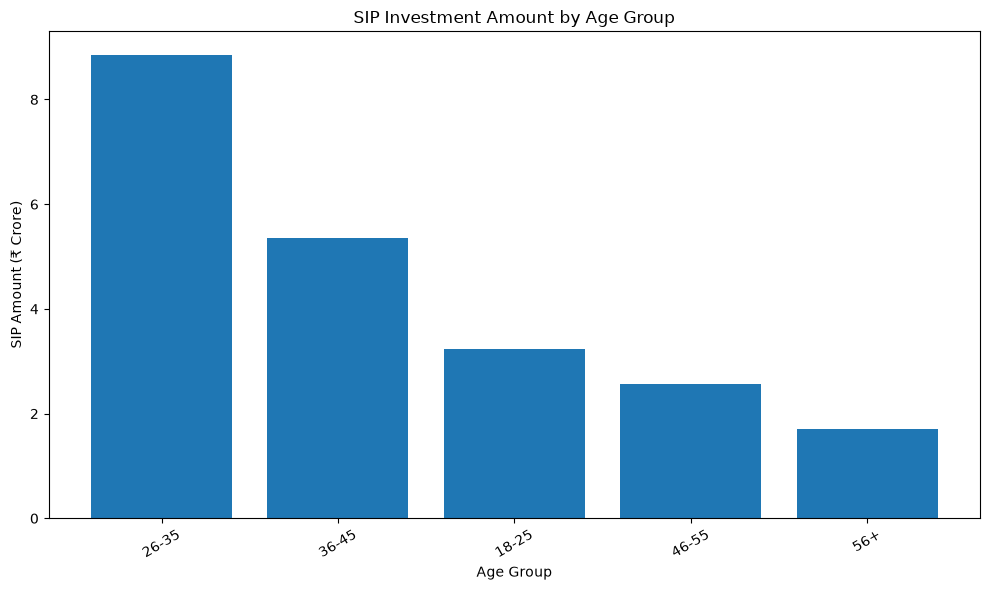

In [75]:
# ============================================
# 31. SIP AMOUNT AGE GROUP CHART
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    sip_by_age.index.astype(str),
    sip_by_age.values / 1_00_00_000
)

plt.title(
    "SIP Investment Amount by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹ Crore)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "sip_amount_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

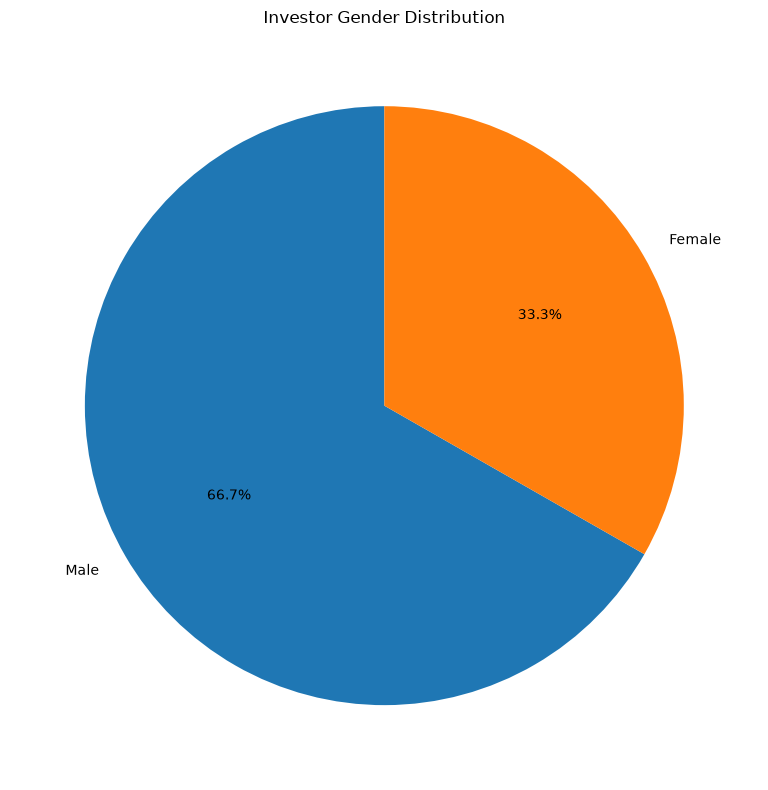

In [77]:
# ============================================
# 32. GENDER DISTRIBUTION
# ============================================

gender_counts = (
    demo.groupby("gender")["investor_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Gender Distribution"
)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "investor_gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

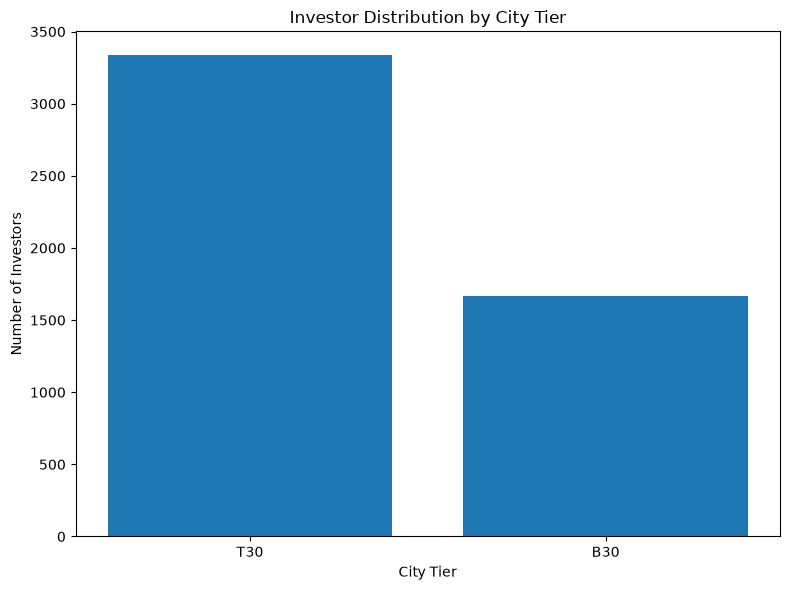

In [ ]:
# ============================================
# 33. CITY TIER DISTRIBUTION
# ============================================

tier_counts = (
    demo.groupby("city_tier")["investor_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))

plt.bar(
    tier_counts.index.astype(str),
    tier_counts.values
)

plt.title(
    "Investor Distribution by City Tier"
)

plt.xlabel("City Tier")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    DASHBOARD / "investor_city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
# ============================================
# 34. GEOGRAPHIC DISTRIBUTION
# ============================================

# Keep SIP transactions only
sip_geo = transactions[
    transactions["transaction_type"]
    .astype(str)
    .str.upper()
    .str.contains("SIP", na=False)
].copy()

# Make amount numeric
sip_geo["amount_inr"] = pd.to_numeric(
    sip_geo["amount_inr"],
    errors="coerce"
)

# Remove invalid records
sip_geo = sip_geo.dropna(
    subset=[
        "state",
        "city_tier",
        "amount_inr"
    ]
)

print("SIP geographic records:", len(sip_geo))

SIP geographic records: 19716


In [80]:
# ============================================
# 35. SIP AMOUNT BY STATE
# ============================================

state_sip = (
    sip_geo
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

print("SIP amount by state:")
print(state_sip)

SIP amount by state:
state
Maharashtra       16445629
Rajasthan         16544233
Delhi             17113608
West Bengal       17495769
Uttar Pradesh     17534858
Karnataka         17696903
Haryana           18176696
Gujarat           18378904
Tamil Nadu        18404368
Telangana         18620216
Punjab            20140064
Madhya Pradesh    20682243
Name: amount_inr, dtype: int64


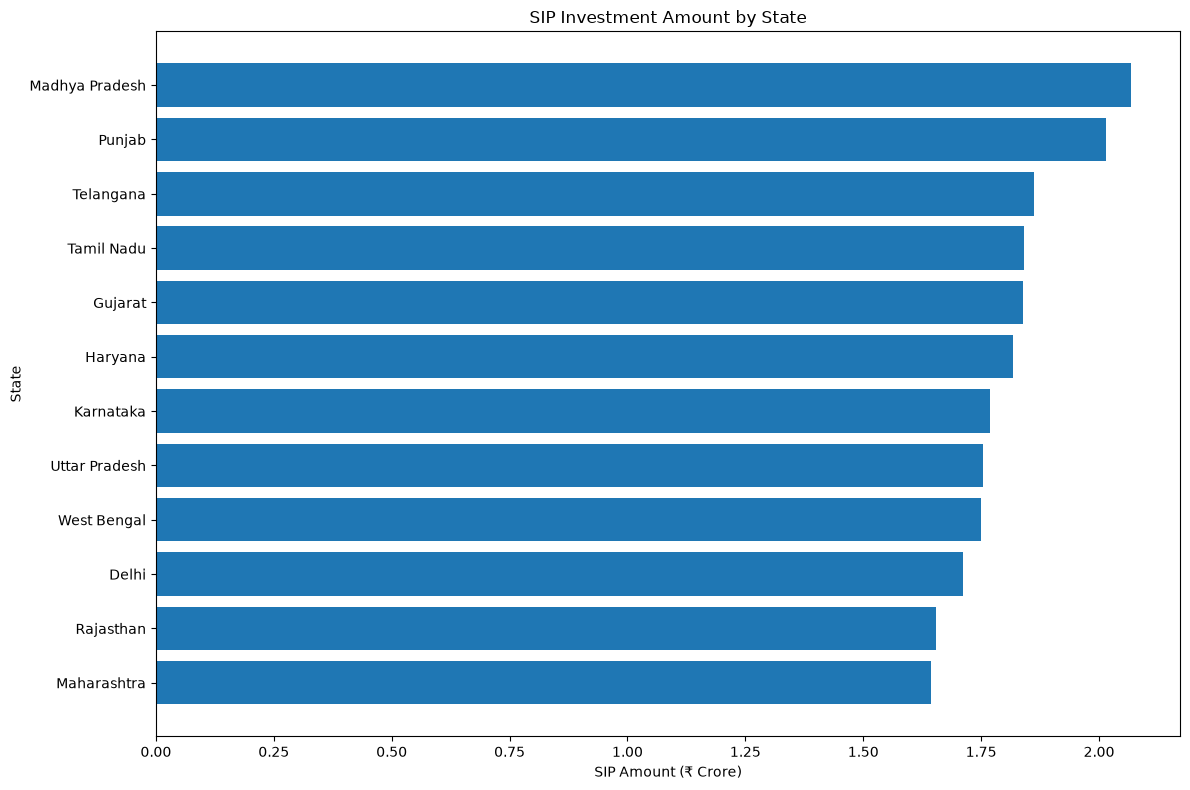

In [81]:
# ============================================
# 36. STATE-WISE SIP AMOUNT
# ============================================

plt.figure(figsize=(12, 8))

plt.barh(
    state_sip.index,
    state_sip.values / 1_00_00_000
)

plt.title(
    "SIP Investment Amount by State"
)

plt.xlabel("SIP Amount (₹ Crore)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    DASHBOARD / "sip_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
# ============================================
# 37. CHECK CITY TIER VALUES
# ============================================

print(
    sip_geo["city_tier"]
    .value_counts()
)

city_tier
T30    13123
B30     6593
Name: count, dtype: int64


In [83]:
# ============================================
# 38. T30 vs B30 SIP DISTRIBUTION
# ============================================

tier_sip = (
    sip_geo
    .groupby("city_tier")["amount_inr"]
    .sum()
)

print("SIP amount by city tier:")
print(tier_sip)

SIP amount by city tier:
city_tier
B30     72304870
T30    144928621
Name: amount_inr, dtype: int64


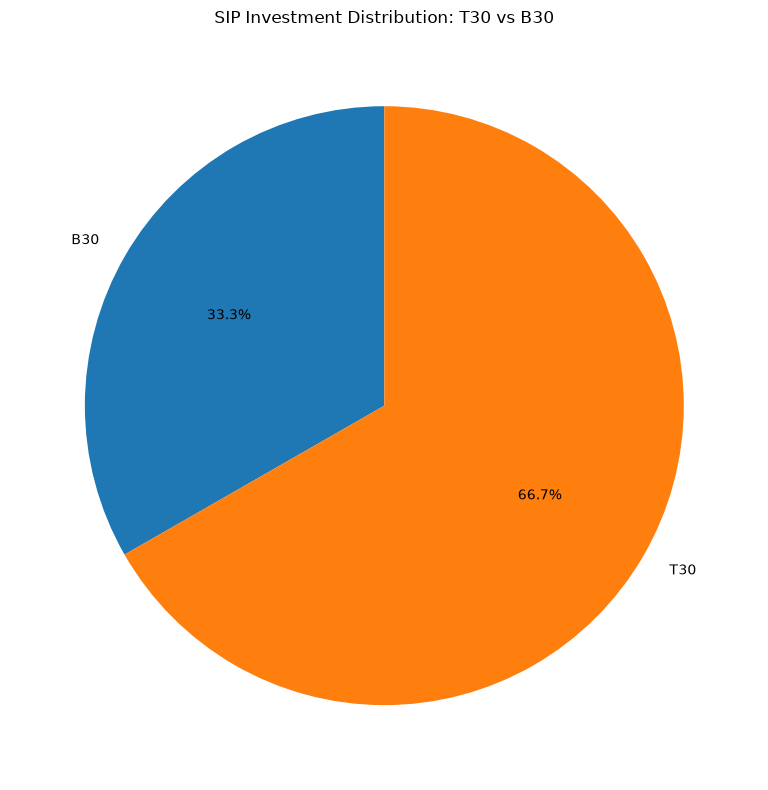

In [84]:
# ============================================
# 39. T30 vs B30 PIE CHART
# ============================================

plt.figure(figsize=(8, 8))

plt.pie(
    tier_sip.values,
    labels=tier_sip.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "SIP Investment Distribution: T30 vs B30"
)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "t30_vs_b30_sip.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
# ============================================
# 40. FIND FOLIO DATASET
# ============================================

folio_file = None

for folder in [DATA_PROCESSED, DATA_RAW]:

    for file in folder.glob("*.csv"):

        try:
            temp = pd.read_csv(file, nrows=5)

            columns = temp.columns.tolist()

            # Search for folio-related columns
            folio_columns = [
                col for col in columns
                if "folio" in col.lower()
            ]

            if len(folio_columns) > 0:
                folio_file = file

                print("Folio dataset found:")
                print(file)

                print("\nFolio-related columns:")
                print(folio_columns)

                print("\nAll columns:")
                print(columns)

                break

        except Exception:
            pass

    if folio_file is not None:
        break


if folio_file is None:
    print("No dataset with a 'folio' column was found.")

Folio dataset found:
c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone\data\raw\06_industry_folio_count.csv

Folio-related columns:
['total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

All columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [86]:
# ============================================
# 41. LOAD FOLIO DATA
# ============================================

folio = pd.read_csv(folio_file)

print("Shape:", folio.shape)

print("\nColumns:")
print(folio.columns.tolist())

print("\nFirst 5 rows:")
display(folio.head())

Shape: (21, 6)

Columns:
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

First 5 rows:


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [87]:
# ============================================
# 42. PREPARE FOLIO DATA
# ============================================

folio["month"] = pd.to_datetime(
    folio["month"],
    errors="coerce"
)

folio["total_folios_crore"] = pd.to_numeric(
    folio["total_folios_crore"],
    errors="coerce"
)

folio = folio.dropna(
    subset=[
        "month",
        "total_folios_crore"
    ]
).copy()

folio = folio.sort_values("month")

print("Folio period:")
print(
    folio["month"].min(),
    "to",
    folio["month"].max()
)

print("\nTotal folio records:", len(folio))

display(
    folio[
        [
            "month",
            "total_folios_crore"
        ]
    ]
)

Folio period:
2022-01-01 00:00:00 to 2025-12-01 00:00:00

Total folio records: 21


,month,total_folios_crore
0,2022-01-01,13.26
1,2022-04-01,13.91
2,2022-07-01,13.85
3,2022-10-01,14.12
4,2023-01-01,14.81
5,2023-04-01,15.54
6,2023-07-01,16.28
7,2023-10-01,16.72
8,2024-01-01,17.78
9,2024-04-01,18.85


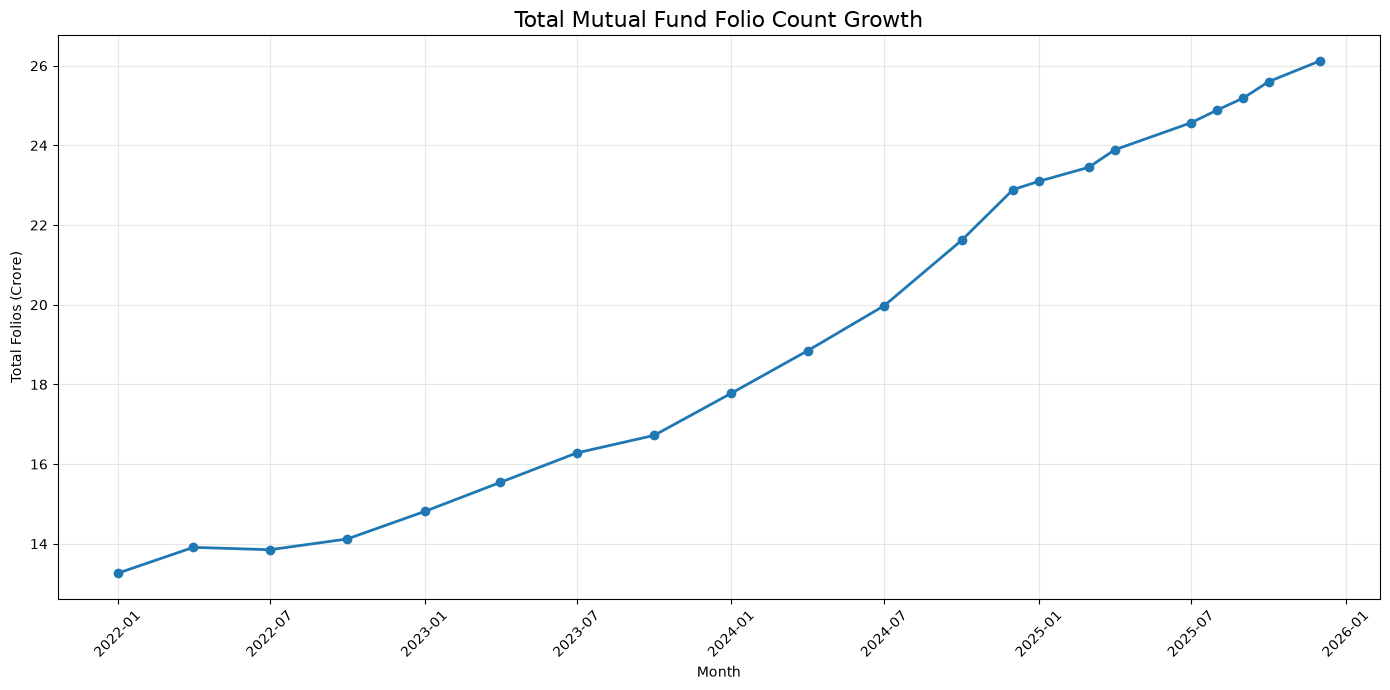

In [88]:
# ============================================
# 43. TOTAL FOLIO COUNT GROWTH
# ============================================

plt.figure(figsize=(14, 7))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title(
    "Total Mutual Fund Folio Count Growth",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.grid(
    True,
    alpha=0.3
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
# ============================================
# 44. FOLIO GROWTH SUMMARY
# ============================================

first_row = folio.iloc[0]
last_row = folio.iloc[-1]

start_value = first_row["total_folios_crore"]
end_value = last_row["total_folios_crore"]

start_month = first_row["month"]
end_month = last_row["month"]

growth_pct = (
    (end_value - start_value)
    / start_value
    * 100
)

print("========================================")
print("FOLIO GROWTH SUMMARY")
print("========================================")

print(
    f"Starting folios ({start_month:%b %Y}): "
    f"{start_value:.2f} Cr"
)

print(
    f"Ending folios ({end_month:%b %Y}): "
    f"{end_value:.2f} Cr"
)

print(
    f"Overall growth: {growth_pct:.2f}%"
)

FOLIO GROWTH SUMMARY
Starting folios (Jan 2022): 13.26 Cr
Ending folios (Dec 2025): 26.12 Cr
Overall growth: 96.98%


In [90]:
# ============================================
# 45. SELECT 10 FUNDS FOR CORRELATION
# ============================================

# Find the 10 schemes with the most NAV observations
top_10_codes = (
    nav.groupby("amfi_code")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

nav_10 = nav[
    nav["amfi_code"].isin(top_10_codes)
].copy()

print("Selected funds:")
print(top_10_codes.tolist())

print(
    "\nNumber of selected funds:",
    nav_10["amfi_code"].nunique()
)

Selected funds:
[100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887, 118632]

Number of selected funds: 10


In [91]:
# ============================================
# 46. DAILY RETURN MATRIX
# ============================================

return_matrix = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

# Remove dates where every fund has no return
return_matrix = return_matrix.dropna(
    how="all"
)

print("Return matrix shape:")
print(return_matrix.shape)

display(return_matrix.head())

Return matrix shape:
(1149, 10)


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360


In [92]:
# ============================================
# 47. NAV RETURN CORRELATION
# ============================================

correlation_matrix = return_matrix.corr()

print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


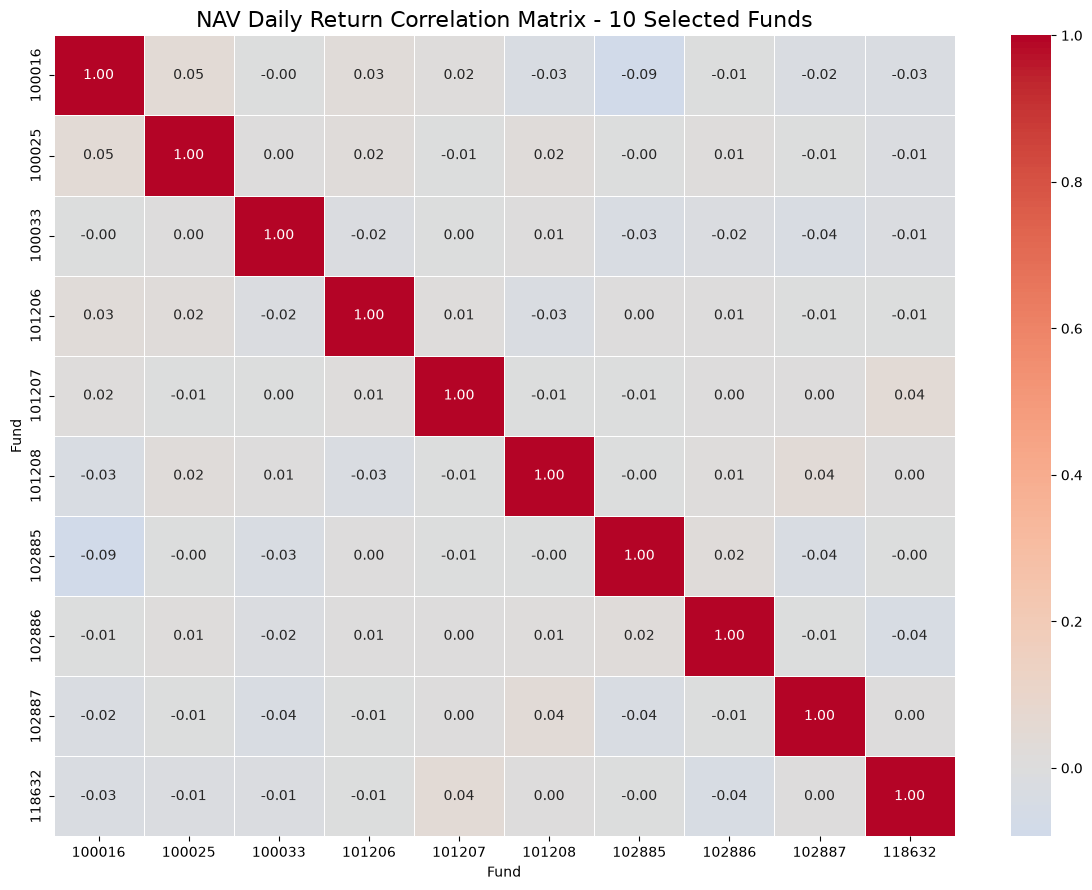

NAV return correlation heatmap created successfully.


In [93]:
# ============================================
# 48. NAV RETURN CORRELATION HEATMAP
# ============================================

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    "NAV Daily Return Correlation Matrix - 10 Selected Funds",
    fontsize=16
)

plt.xlabel("Fund")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    DASHBOARD / "nav_return_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "NAV return correlation heatmap created successfully."
)

In [95]:
# ============================================
# LOAD PORTFOLIO HOLDINGS
# ============================================

# Find the holdings CSV automatically
holdings_file = None

for folder in [DATA_PROCESSED, DATA_RAW]:

    for file in folder.glob("*.csv"):

        try:
            temp = pd.read_csv(file, nrows=5)

            columns = temp.columns.tolist()

            if (
                "sector" in columns
                and "weight_pct" in columns
                and "stock_symbol" in columns
            ):
                holdings_file = file
                break

        except Exception:
            pass

    if holdings_file is not None:
        break


if holdings_file is None:
    raise FileNotFoundError(
        "Could not find the portfolio holdings CSV."
    )


print("Holdings file found:")
print(holdings_file)

holdings = pd.read_csv(holdings_file)

print("\nHoldings loaded successfully")
print("Shape:", holdings.shape)

print("\nColumns:")
print(holdings.columns.tolist())

display(holdings.head())

Holdings file found:
c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone\data\raw\09_portfolio_holdings.csv

Holdings loaded successfully
Shape: (322, 8)

Columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [97]:
# ============================================
# 50. CORRECT SECTOR ALLOCATION
# ============================================

# Make sure weight is numeric
holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

# Remove invalid records
sector_data = holdings.dropna(
    subset=["amfi_code", "sector", "weight_pct"]
).copy()

# First calculate sector weight within each fund
fund_sector = (
    sector_data
    .groupby(
        ["amfi_code", "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

# Average sector allocation across all funds
sector_allocation = (
    fund_sector
    .groupby("sector")["weight_pct"]
    .mean()
    .sort_values(ascending=False)
)

print("Correct average sector allocation:")
print(sector_allocation)

print(
    "\nTotal allocation:",
    sector_allocation.sum()
)

Correct average sector allocation:
sector
Banking           21.742000
Pharma            18.520455
IT                16.869259
Consumer Goods    14.178889
Utilities         13.975789
Automobile        12.448077
Diversified       12.087857
FMCG              12.058421
NBFC              10.826364
Infrastructure    10.675556
Telecom            9.708000
Energy             9.070000
Paints             8.986000
Cement             8.752500
Name: weight_pct, dtype: float64

Total allocation: 179.8991664777717


In [98]:
# ============================================
# 51. TOP 10 SECTORS + OTHER
# ============================================

top_10 = sector_allocation.head(10)

other = sector_allocation.iloc[10:].sum()

sector_chart = top_10.copy()

if other > 0:
    sector_chart["Other"] = other

print("Sector allocation for chart:")
print(sector_chart)

print(
    "\nChart total:",
    sector_chart.sum()
)

Sector allocation for chart:
sector
Banking           21.742000
Pharma            18.520455
IT                16.869259
Consumer Goods    14.178889
Utilities         13.975789
Automobile        12.448077
Diversified       12.087857
FMCG              12.058421
NBFC              10.826364
Infrastructure    10.675556
Other             36.516500
Name: weight_pct, dtype: float64

Chart total: 179.89916647777173


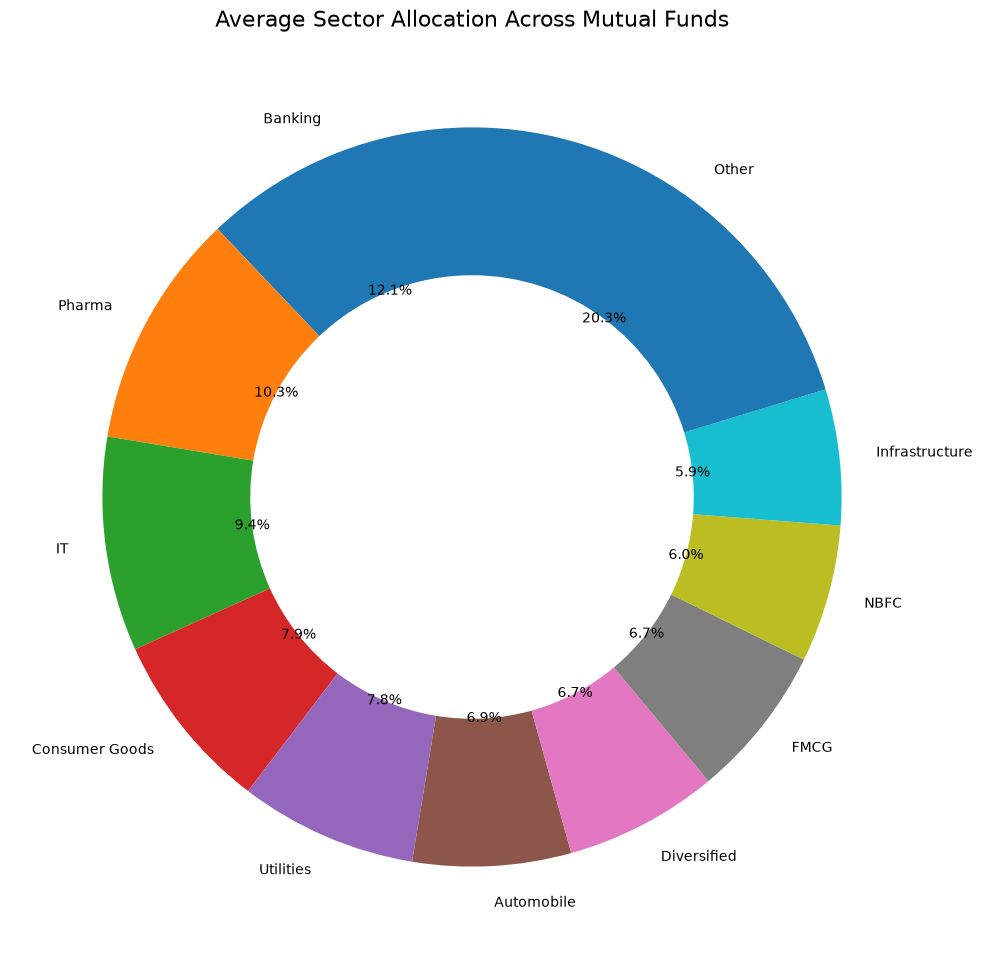

Sector allocation donut created successfully.


In [99]:
# ============================================
# 52. SECTOR ALLOCATION DONUT
# ============================================

plt.figure(figsize=(10, 10))

plt.pie(
    sector_chart.values,
    labels=sector_chart.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "width": 0.40
    }
)

plt.title(
    "Average Sector Allocation Across Mutual Funds",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    DASHBOARD / "sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Sector allocation donut created successfully."
)

In [101]:
# ============================================
# 53. BUSINESS INSIGHTS
# ============================================

print("=" * 70)
print("MUTUAL FUND EDA - KEY BUSINESS INSIGHTS")
print("=" * 70)


# ------------------------------------------------
# 1. AUM LEADER
# ------------------------------------------------

if "aum_yearly" in globals() and not aum_yearly.empty:

    latest_year = aum_yearly["year"].max()

    latest_aum = aum_yearly[
        aum_yearly["year"] == latest_year
    ].sort_values(
        "aum_lakh_crore",
        ascending=False
    )

    leader = latest_aum.iloc[0]

    print("\n1. AUM LEADER")
    print(
        f"{leader['fund_house']} had the highest AUM "
        f"in {latest_year}: "
        f"₹{leader['aum_lakh_crore']:.2f} lakh crore."
    )


# ------------------------------------------------
# 2. SIP INFLOW GROWTH
# ------------------------------------------------

if "sip" in globals() and not sip.empty:

    first_sip = sip.iloc[0]
    last_sip = sip.iloc[-1]

    sip_growth = (
        (last_sip["sip_inflow_crore"]
         - first_sip["sip_inflow_crore"])
        / first_sip["sip_inflow_crore"]
        * 100
    )

    print("\n2. SIP INFLOW TREND")
    print(
        f"SIP inflow changed from "
        f"₹{first_sip['sip_inflow_crore']:,.2f} crore "
        f"to ₹{last_sip['sip_inflow_crore']:,.2f} crore, "
        f"a change of {sip_growth:.2f}%."
    )


# ------------------------------------------------
# 3. HIGHEST SIP MONTH
# ------------------------------------------------

if "sip" in globals() and not sip.empty:

    max_sip = sip.loc[
        sip["sip_inflow_crore"].idxmax()
    ]

    print("\n3. HIGHEST SIP INFLOW MONTH")
    print(
        f"{max_sip['month']:%B %Y} recorded the highest "
        f"SIP inflow of "
        f"₹{max_sip['sip_inflow_crore']:,.2f} crore."
    )


# ------------------------------------------------
# 4. FOLIO GROWTH
# ------------------------------------------------

if "folio" in globals() and not folio.empty:

    first_folio = folio.iloc[0]
    last_folio = folio.iloc[-1]

    folio_growth = (
        (last_folio["total_folios_crore"]
         - first_folio["total_folios_crore"])
        / first_folio["total_folios_crore"]
        * 100
    )

    print("\n4. FOLIO GROWTH")
    print(
        f"Total folios increased from "
        f"{first_folio['total_folios_crore']:.2f} crore "
        f"to {last_folio['total_folios_crore']:.2f} crore, "
        f"a growth of {folio_growth:.2f}%."
    )


# ------------------------------------------------
# 5. TOP FUND CATEGORY BY INFLOW
# ------------------------------------------------

if "category_inflow" in globals() and not category_inflow.empty:

    category_total = (
        category_inflow
        .groupby("category")["net_inflow_crore"]
        .sum()
        .sort_values(ascending=False)
    )

    top_category = category_total.index[0]

    print("\n5. TOP CATEGORY BY NET INFLOW")
    print(
        f"{top_category} recorded the highest cumulative "
        f"net inflow of "
        f"₹{category_total.iloc[0]:,.2f} crore."
    )


# ------------------------------------------------
# 6. HIGHEST SECTOR EXPOSURE
# ------------------------------------------------

if "sector_allocation" in globals() and not sector_allocation.empty:

    top_sector = sector_allocation.index[0]
    top_sector_value = sector_allocation.iloc[0]

    print("\n6. HIGHEST SECTOR EXPOSURE")
    print(
        f"{top_sector} had the highest average sector "
        f"allocation at {top_sector_value:.2f}%."
    )


# ------------------------------------------------
# 7. TOP STATE BY SIP
# ------------------------------------------------

if "state_sip" in globals() and not state_sip.empty:

    top_state = state_sip.index[-1]
    top_state_value = state_sip.iloc[-1]

    print("\n7. TOP STATE BY SIP INVESTMENT")
    print(
        f"{top_state} recorded the highest SIP investment "
        f"of approximately "
        f"₹{top_state_value / 1_00_00_000:,.2f} crore."
    )


# ------------------------------------------------
# 8. LARGEST AGE GROUP
# ------------------------------------------------

if "age_counts" in globals() and not age_counts.empty:

    top_age = age_counts.index[0]

    print("\n8. DOMINANT INVESTOR AGE GROUP")
    print(
        f"The {top_age} age group has the largest "
        f"number of unique investors."
    )


# ------------------------------------------------
# 9. LARGEST CITY-TIER SEGMENT
# ------------------------------------------------

if "tier_counts" in globals() and not tier_counts.empty:

    top_tier = tier_counts.index[0]

    print("\n9. DOMINANT CITY-TIER SEGMENT")
    print(
        f"{top_tier} has the largest number of "
        f"unique investors."
    )


# ------------------------------------------------
# ------------------------------------------------
# 10. FUND RETURN CORRELATION
# ------------------------------------------------

if "correlation_matrix" in globals():

    corr = correlation_matrix.copy()

    # Get only unique fund pairs
    corr_pairs = []

    columns = corr.columns.tolist()

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            value = corr.iloc[i, j]

            if pd.notna(value):

                corr_pairs.append(
                    (
                        columns[i],
                        columns[j],
                        value
                    )
                )

    if len(corr_pairs) > 0:

        # Find strongest correlation
        strongest_pair = max(
            corr_pairs,
            key=lambda x: x[2]
        )

        print("\n10. HIGHEST RETURN CORRELATION")

        print(
            f"The strongest pairwise daily-return "
            f"correlation is between "
            f"{strongest_pair[0]} and "
            f"{strongest_pair[1]}, "
            f"with correlation "
            f"{strongest_pair[2]:.2f}."
        )

    else:

        print(
            "\n10. HIGHEST RETURN CORRELATION"
        )

        print(
            "Not enough valid correlation pairs."
        )

MUTUAL FUND EDA - KEY BUSINESS INSIGHTS

1. AUM LEADER
SBI Mutual Fund had the highest AUM in 2025: ₹12.50 lakh crore.

2. SIP INFLOW TREND
SIP inflow changed from ₹11,517.00 crore to ₹31,002.00 crore, a change of 169.18%.

3. HIGHEST SIP INFLOW MONTH
December 2025 recorded the highest SIP inflow of ₹31,002.00 crore.

4. FOLIO GROWTH
Total folios increased from 13.26 crore to 26.12 crore, a growth of 96.98%.

5. TOP CATEGORY BY NET INFLOW
Liquid recorded the highest cumulative net inflow of ₹451,275.00 crore.

6. HIGHEST SECTOR EXPOSURE
Banking had the highest average sector allocation at 21.74%.

7. TOP STATE BY SIP INVESTMENT
Madhya Pradesh recorded the highest SIP investment of approximately ₹2.07 crore.

8. DOMINANT INVESTOR AGE GROUP
The 26-35 age group has the largest number of unique investors.

9. DOMINANT CITY-TIER SEGMENT
T30 has the largest number of unique investors.

10. HIGHEST RETURN CORRELATION
The strongest pairwise daily-return correlation is between 100016 and 100025

In [102]:
# ============================================
# 54. SAVE BUSINESS INSIGHTS
# ============================================

insights_file = REPORTS / "eda_business_insights.txt"

with open(
    insights_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "MUTUAL FUND EDA - KEY BUSINESS INSIGHTS\n"
    )

    f.write("=" * 60 + "\n\n")

    # AUM
    if "aum_yearly" in globals() and not aum_yearly.empty:

        latest_year = aum_yearly["year"].max()

        latest_aum = aum_yearly[
            aum_yearly["year"] == latest_year
        ].sort_values(
            "aum_lakh_crore",
            ascending=False
        )

        leader = latest_aum.iloc[0]

        f.write(
            f"1. AUM Leader: {leader['fund_house']} "
            f"had the highest AUM in {latest_year} "
            f"at ₹{leader['aum_lakh_crore']:.2f} lakh crore.\n"
        )

    # SIP
    if "sip" in globals() and not sip.empty:

        first_sip = sip.iloc[0]
        last_sip = sip.iloc[-1]

        growth = (
            (last_sip["sip_inflow_crore"]
             - first_sip["sip_inflow_crore"])
            / first_sip["sip_inflow_crore"]
            * 100
        )

        f.write(
            f"2. SIP Trend: SIP inflow changed by "
            f"{growth:.2f}% over the available period.\n"
        )

    # Folios
    if "folio" in globals() and not folio.empty:

        first_folio = folio.iloc[0]
        last_folio = folio.iloc[-1]

        growth = (
            (last_folio["total_folios_crore"]
             - first_folio["total_folios_crore"])
            / first_folio["total_folios_crore"]
            * 100
        )

        f.write(
            f"3. Folio Growth: Total folios changed by "
            f"{growth:.2f}% over the available period.\n"
        )

    # Category
    if "category_inflow" in globals():

        category_total = (
            category_inflow
            .groupby("category")["net_inflow_crore"]
            .sum()
            .sort_values(ascending=False)
        )

        f.write(
            f"4. Top Category: "
            f"{category_total.index[0]}.\n"
        )

    # Sector
    if "sector_allocation" in globals():

        f.write(
            f"5. Top Sector: "
            f"{sector_allocation.index[0]} "
            f"({sector_allocation.iloc[0]:.2f}%).\n"
        )

print(
    f"Insights saved to:\n{insights_file}"
)

Insights saved to:
c:\Users\kiran\OneDrive\Desktop\bluestock_mf_capstone\reports\eda_business_insights.txt
